Car vs truc CNN model 90%

In [115]:
import tensorflow as tf
import pandas as pd

from keras import Sequential, layers, callbacks, losses, utils, optimizers, applications
from keras.preprocessing import image_dataset_from_directory

Preprocess data and create the training and validation split 80% / 20%.

In [116]:
img_height = 299
img_width = 299

batch_size = 2

seed = 123

buffer = 1000

data_dir = "../data/tests/car_vs_truck"

input_shape = [img_height,img_width, 3]

ds_train = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    seed=seed,
    subset="training",
    image_size=(img_height,img_width),
    batch_size=batch_size,
    shuffle=True
    )

ds_valid= image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    seed=seed,
    subset="validation",
    image_size=(img_height,img_width),
    batch_size=batch_size,
    shuffle=True
    )
#ds_valid.shuffle(buffer_size=buffer)
#ds_train.shuffle(buffer_size=buffer)
class_names = ds_train.class_names # type: ignore
num_classes = 2
#print(class_names)

Found 10168 files belonging to 2 classes.
Using 8135 files for training.
Found 10168 files belonging to 2 classes.
Using 2033 files for validation.


In [117]:
%%capture
for image_batch, labels_batch in ds_train:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

In [118]:
AUTOTUNE = tf.data.AUTOTUNE

ds_train = ds_train.cache().prefetch(buffer_size=AUTOTUNE)
ds_valid = ds_valid.cache().prefetch(buffer_size=AUTOTUNE)



In [ ]:
padding = "same"

body = applications.Xception(weights="imagenet")
body.trainable = False
model_layers = [
    
    #Preprocessing
    
    # resacle values to 
    layers.Rescaling(1./255),
    
    #layers.RandomFlip(mode="vertical_and_horizontal"),
    #layers.RandomContrast(0.5),
    #layers.RandomZoom(0.2,0.2),
    #layers.RandomSaturation(0.5),
    #layers.Solarization(),
    #layers.RandomGrayscale(),
    #layers.RandomGaussianBlur(),
    #layers.RandomRotation(0.3),
    #layers.Rescaling(1./255),
    # Body
    
    body,
    
    # Classifier head
    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64,activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
]


In [120]:

model = Sequential(layers=model_layers)

early_stopping = callbacks.EarlyStopping(patience=5,
                                      min_delta=0.001,restore_best_weights=True)

optimizer = optimizers.Adam()
model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=['binary_accuracy'],
)
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_16 (Rescaling)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 1000)           │    22,910,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,910,480 (87.40 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 22,910,480 (87.40 MB)

Train the model

In [121]:
history = model.fit(
    ds_train,
    validation_data=ds_valid,
    callbacks=[early_stopping],
    epochs=50,
)

Epoch 1/50
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 159s 37ms/step - binary_accuracy: 0.8457 - loss: 0.3708 - val_binary_accuracy: 0.8647 - val_loss: 0.3178
Epoch 2/50
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 136s 33ms/step - binary_accuracy: 0.8607 - loss: 0.3382 - val_binary_accuracy: 0.8637 - val_loss: 0.3092
Epoch 3/50
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 137s 34ms/step - binary_accuracy: 0.8642 - loss: 0.3254 - val_binary_accuracy: 0.8716 - val_loss: 0.2995
Epoch 4/50
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 137s 34ms/step - binary_accuracy: 0.8701 - loss: 0.3140 - val_binary_accuracy: 0.8731 - val_loss: 0.2939
Epoch 5/50
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 137s 34ms/step - binary_accuracy: 0.8731 - loss: 0.3077 - val_binary_accuracy: 0.8765 - val_loss: 0.2892
Epoch 6/50
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 137s 34ms/step - binary_accuracy: 0.8758 - loss: 0.2984 - val_binary_accuracy: 0.8770 - val_loss: 0.2863
Epoch 7/50
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 137s 34ms/step - binary_accuracy: 0.8810 - loss: 0.2906 - val_binary_accurac

<Axes: >

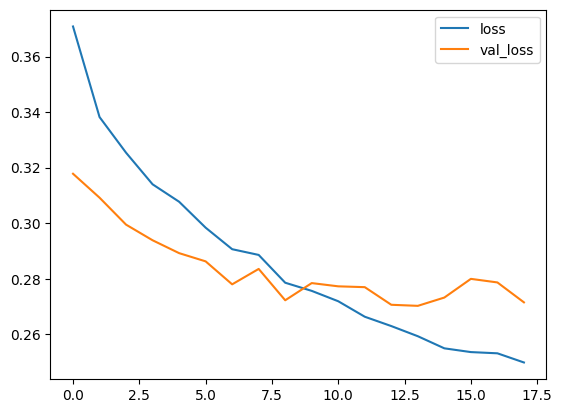

In [122]:

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()